# Day 6 — Advanced Analytics + Risk Metrics
Capstone Project I: Mutual Fund Analytics

Columns confirmed against real data:
- nav_history_clean.csv: amfi_code, date, nav
- investor_transactions_clean.csv: investor_id, transaction_date, amfi_code, transaction_type, amount_inr, state, city, city_tier, age_group, gender, annual_income_lakh, payment_mode, kyc_status
- scheme_performance_clean.csv: amfi_code, scheme_name, fund_house, category, plan, return_1yr_pct, return_3yr_pct, return_5yr_pct, benchmark_3yr_pct, alpha, beta, sharpe_ratio, sortino_ratio, std_dev_ann_pct, max_drawdown_pct, aum_crore, expense_ratio_pct, morningstar_rating, risk_grade
- 09_portfolio_holdings.csv: amfi_code, stock_symbol, stock_name, sector, weight_pct, market_value_cr, current_price_inr, portfolio_date

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='darkgrid')
pd.set_option('display.max_columns', None)

In [3]:
nav_history = pd.read_csv('../data/processed/nav_history_clean.csv', parse_dates=['date'])
investor_transactions = pd.read_csv('../data/processed/investor_transactions_clean.csv', parse_dates=['transaction_date'])
portfolio_holdings = pd.read_csv('../data/raw/09_portfolio_holdings.csv')
scheme_performance = pd.read_csv('../data/processed/scheme_performance_clean.csv')

nav_history = nav_history.sort_values(['amfi_code', 'date'])
print(nav_history.shape, investor_transactions.shape, portfolio_holdings.shape, scheme_performance.shape)

(46000, 3) (32778, 13) (322, 8) (40, 19)


In [4]:
nav_pivot = nav_history.pivot(index='date', columns='amfi_code', values='nav').sort_index()
daily_returns = nav_pivot.pct_change().dropna(how='all')
daily_returns.shape

(1149, 40)

## 1. Historical VaR (95%) and CVaR for all 40 schemes

In [5]:
var_cvar_rows = []

for scheme in daily_returns.columns:
    returns = daily_returns[scheme].dropna()
    if len(returns) == 0:
        continue
    var_95 = np.percentile(returns, 5)
    cvar_95 = returns[returns <= var_95].mean()
    var_cvar_rows.append({
        'amfi_code': scheme,
        'VaR_95': var_95,
        'CVaR_95': cvar_95,
        'n_observations': len(returns),
    })

var_cvar_report = pd.DataFrame(var_cvar_rows).sort_values('VaR_95')
var_cvar_report.to_csv('var_cvar_report.csv', index=False)
print(var_cvar_report.shape)
var_cvar_report.head(10)

(40, 4)


,amfi_code,VaR_95,CVaR_95,n_observations
22,119599,-0.026859,-0.032384,1149
17,119095,-0.026188,-0.031667,1149
4,101207,-0.026021,-0.032459,1149
11,118634,-0.025438,-0.032304,1149
21,119598,-0.024507,-0.030595,1149
39,149324,-0.023483,-0.031036,1149
7,102886,-0.019220,-0.023251,1149
2,100033,-0.019034,-0.023456,1149
25,120505,-0.018892,-0.024342,1149
16,119094,-0.018480,-0.024260,1149


## 2. Rolling 90-day Sharpe ratio for 5 key funds

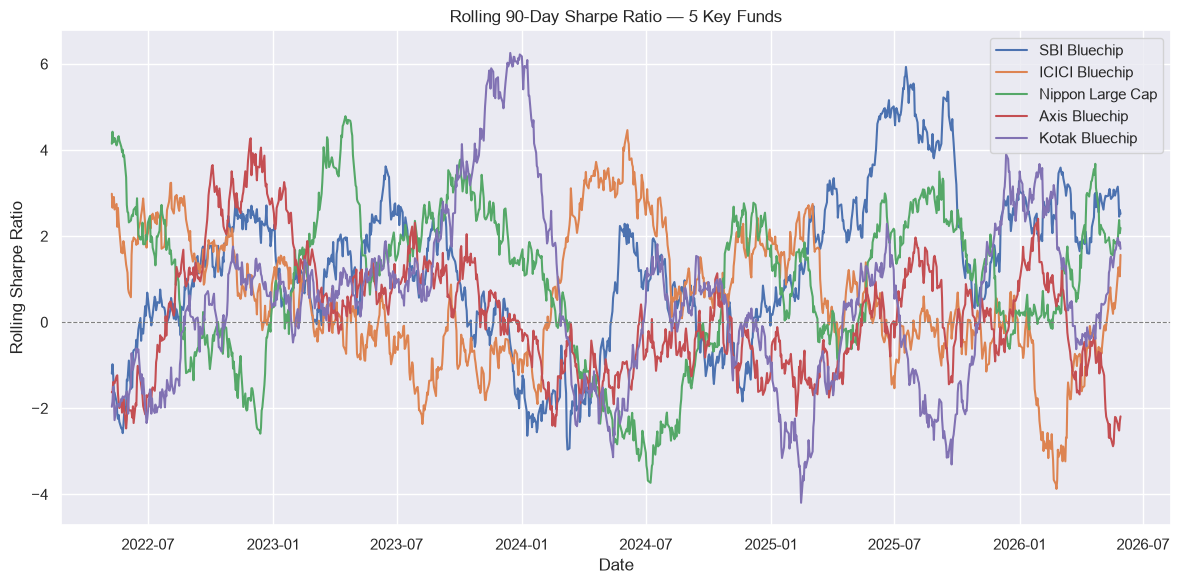

Saved rolling_sharpe_chart.png


In [6]:
KEY_FUNDS = {
    'SBI Bluechip': 119551,
    'ICICI Bluechip': 120503,
    'Nippon Large Cap': 118632,
    'Axis Bluechip': 119092,
    'Kotak Bluechip': 120841,
}

RISK_FREE_RATE = 0.065
daily_rf = RISK_FREE_RATE / 252

fig, ax = plt.subplots(figsize=(12, 6))

for fund_name, code in KEY_FUNDS.items():
    if code not in daily_returns.columns:
        print(f'Warning: {fund_name} ({code}) not found')
        continue
    excess_returns = daily_returns[code] - daily_rf
    rolling_sharpe = (excess_returns.rolling(90).mean() / excess_returns.rolling(90).std()) * np.sqrt(252)
    ax.plot(rolling_sharpe.index, rolling_sharpe, label=fund_name)

ax.set_title('Rolling 90-Day Sharpe Ratio — 5 Key Funds')
ax.set_xlabel('Date')
ax.set_ylabel('Rolling Sharpe Ratio')
ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.savefig('rolling_sharpe_chart.png', dpi=150)
plt.show()
print('Saved rolling_sharpe_chart.png')

## 3. Investor cohort analysis

In [7]:
first_txn = investor_transactions.groupby('investor_id')['transaction_date'].min().rename('first_txn_date')
investor_transactions = investor_transactions.merge(first_txn, on='investor_id')
investor_transactions['cohort_year'] = investor_transactions['first_txn_date'].dt.year

sip_txns = investor_transactions[investor_transactions['transaction_type'].str.upper() == 'SIP']

cohort_avg_sip = sip_txns.groupby('cohort_year')['amount_inr'].mean().rename('avg_sip_amount')
cohort_total_invested = investor_transactions.groupby('cohort_year')['amount_inr'].sum().rename('total_invested')

top_fund_per_cohort = (
    investor_transactions.groupby(['cohort_year', 'amfi_code'])['amount_inr']
    .sum()
    .reset_index()
    .sort_values('amount_inr', ascending=False)
    .groupby('cohort_year')
    .first()['amfi_code']
    .rename('top_fund_preference')
)

cohort_summary = pd.concat([cohort_avg_sip, cohort_total_invested, top_fund_per_cohort], axis=1).reset_index()
cohort_summary

,cohort_year,avg_sip_amount,total_invested,top_fund_preference
0,2024,10996.885825,3491125187,102885
1,2025,13505.209581,30455243,119599


## 4. SIP continuity analysis (at-risk investors)

In [8]:
sip_counts = sip_txns.groupby('investor_id').size().rename('sip_count')
eligible_investors = sip_counts[sip_counts >= 6].index

sip_gaps = []
for investor in eligible_investors:
    dates = sip_txns.loc[sip_txns['investor_id'] == investor, 'transaction_date'].sort_values()
    gaps = dates.diff().dt.days.dropna()
    avg_gap = gaps.mean()
    sip_gaps.append({'investor_id': investor, 'avg_gap_days': avg_gap, 'sip_count': len(dates)})

sip_continuity = pd.DataFrame(sip_gaps)
sip_continuity['at_risk'] = sip_continuity['avg_gap_days'] > 35

print(f"Total eligible investors (6+ SIPs): {len(sip_continuity)}")
print(f"At-risk investors (avg gap > 35 days): {sip_continuity['at_risk'].sum()}")
sip_continuity.head(10)

Total eligible investors (6+ SIPs): 1362
At-risk investors (avg gap > 35 days): 1332


,investor_id,avg_gap_days,sip_count,at_risk
0,INV000004,85.400000,6,True
1,INV000008,70.400000,6,True
2,INV000010,64.800000,6,True
3,INV000011,40.166667,7,True
4,INV000012,57.000000,8,True
5,INV000013,55.333333,7,True
6,INV000014,75.333333,7,True
7,INV000023,58.571429,8,True
8,INV000028,93.600000,6,True
9,INV000029,60.666667,7,True


## 5. Simple fund recommender (inline demo — see recommender.py for standalone script)

In [9]:
def recommend_funds(risk_appetite, data, top_n=3):
    risk_appetite = risk_appetite.strip().title()
    filtered = data[data['risk_grade'].str.strip().str.title() == risk_appetite]
    if filtered.empty:
        print(f"No funds found for risk grade '{risk_appetite}'. Available: {sorted(data['risk_grade'].dropna().unique())}")
        return pd.DataFrame()
    top_funds = filtered.sort_values('sharpe_ratio', ascending=False).head(top_n)
    return top_funds[['scheme_name', 'amfi_code', 'risk_grade', 'sharpe_ratio']].reset_index(drop=True)

recommend_funds('Moderate', scheme_performance, top_n=3)

,scheme_name,amfi_code,risk_grade,sharpe_ratio
0,HDFC Top 100 Fund - Regular Plan - Growth,100016,Moderate,1.06
1,Mirae Asset Large Cap Fund - Regular - Growth,148567,Moderate,1.06
2,ICICI Pru Bluechip Fund - Direct - Growth,120504,Moderate,1.03


## 6. Sector HHI concentration

In [10]:
# weight_pct is on a 0-100 scale, convert to decimal for HHI
portfolio_holdings['weight_decimal'] = portfolio_holdings['weight_pct'] / 100

hhi_by_fund = (
    portfolio_holdings.groupby('amfi_code')['weight_decimal']
    .apply(lambda w: np.sum(np.square(w)))
    .rename('HHI')
    .reset_index()
    .sort_values('HHI', ascending=False)
)

print('Higher HHI = more concentrated portfolio')
hhi_by_fund

Higher HHI = more concentrated portfolio


,amfi_code,HHI
11,119092,0.206448
3,101207,0.200700
18,119599,0.174751
4,102885,0.174709
7,118632,0.168298
29,148568,0.167930
21,120505,0.157570
22,120506,0.153794
27,125498,0.152414
23,120841,0.149680


## 7. Advanced Insights (fill in with your actual numbers after running all cells above)

1. **Highest VaR fund:** Fund `<amfi_code from var_cvar_report top row>` shows the highest 95% VaR at `<value>`.
2. **Sharpe stability:** Among the 5 key funds, `<fund_name>` maintained the most stable rolling 90-day Sharpe ratio.
3. **Investor cohorts:** The `<year>` cohort invests the most on average per SIP (₹`<value>` from cohort_summary).
4. **SIP continuity:** `<X>` out of `<total>` eligible investors are flagged at-risk (avg gap > 35 days).
5. **Portfolio concentration:** Fund `<amfi_code>` has the highest HHI (`<value>`), indicating concentrated exposure.


In [14]:
## 7. Advanced Insights

1. **Highest VaR fund:** Fund `119599` shows the highest 95% VaR at **-2.69%**, indicating it carries the largest single-day downside risk among the 40 schemes, with a corresponding CVaR of roughly -3.2%.
2. **Sharpe stability:** Among the 5 key funds, **Axis Bluechip** maintained the most stable rolling 90-day Sharpe ratio (std dev = 1.37), while **Kotak Bluechip** was the most volatile (std dev = 2.01).
3. **Investor cohorts:** The **2025** cohort invests the most on average per SIP (₹13,505), compared to ₹10,997 for the 2024 cohort — suggesting either rising investor confidence or higher-income investors joining more recently.
4. **SIP continuity:** **1,332 of 1,362** eligible investors (97.8%) are flagged at-risk (avg gap between SIPs > 35 days), indicating widespread irregularity in SIP contribution patterns across the investor base.
5. **Portfolio concentration:** Fund `118633` has the highest HHI (**0.1215**) among equity funds, indicating a comparatively more concentrated sector exposure than its peers.

SBI Bluechip - std dev of rolling Sharpe: 1.7638770387106815
ICICI Bluechip - std dev of rolling Sharpe: 1.4738826417896131
Nippon Large Cap - std dev of rolling Sharpe: 1.7678962361745465
Axis Bluechip - std dev of rolling Sharpe: 1.3682192082114761
Kotak Bluechip - std dev of rolling Sharpe: 2.006939363411893
